# Giovanelli (1946) — A Theory of Chromospheric Flares
# Giovanelli (1946) — 채층 플레어 이론

## Implementation of Key Calculations / 핵심 계산 구현

This notebook reproduces and extends the key quantitative results from Giovanelli's 1946 Nature letter:

이 노트북은 Giovanelli의 1946년 Nature letter의 핵심 정량적 결과를 재현하고 확장합니다:

1. **Sunspot coil model / 흑점 코일 모델** — Induced electric and magnetic fields from a growing sunspot
2. **Ionization condition / 이온화 조건** — Threshold for electron excitation of hydrogen at neutral points vs. magnetized regions
3. **Chromospheric conductivity / 채층 전도도** — Direct and transverse conductivities as functions of magnetic field
4. **Neutral point geometry / 중성점 기하학** — Visualization of magnetic field topology and neutral point locations

**Reference / 참고문헌**: Giovanelli, R. G. (1946). *Nature*, 158, 81–82. [DOI: 10.1038/158081a0]

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from matplotlib.colors import Normalize
import matplotlib.gridspec as gridspec

plt.rcParams.update({
    "figure.dpi": 120,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
})

# --- Physical constants (CGS-Gaussian) ---
e_cgs = 4.803e-10       # electron charge (statcoulomb)
e_emu = e_cgs / 2.998e10  # electron charge (EMU / abcoulomb)
m_e = 9.109e-28         # electron mass (g)
c = 2.998e10            # speed of light (cm/s)
k_B = 1.381e-16         # Boltzmann constant (erg/K)

print("Constants loaded. All calculations in CGS-Gaussian units.")
print(f"  e (statcoulomb) = {e_cgs:.3e}")
print(f"  m_e (g)         = {m_e:.3e}")
print(f"  c (cm/s)        = {c:.3e}")

Constants loaded. All calculations in CGS-Gaussian units.
  e (statcoulomb) = 4.803e-10
  m_e (g)         = 9.109e-28
  c (cm/s)        = 2.998e+10


## 1. Sunspot Coil Model / 흑점 코일 모델

Giovanelli models a growing sunspot as a circular current coil. The sunspot grows uniformly over 50 hours to a diameter of $7 \times 10^9$ cm with a maximum magnetic field of 2,000 gauss.

Giovanelli는 성장하는 흑점을 원형 전류 코일로 모델링합니다. 흑점은 50시간에 걸쳐 균일하게 성장하여 직경 $7 \times 10^9$ cm, 최대 자기장 2,000 gauss에 도달합니다.

The magnetic field of a circular current loop on its axis is:

$$B_z(r, 0) = \frac{2\pi I a^2}{c (a^2 + r^2)^{3/2}}$$

and the induced electric field from a time-varying magnetic flux is:

$$E_\phi = -\frac{1}{2\pi r c} \frac{d\Phi}{dt}$$

In [2]:
# --- Sunspot parameters (from Giovanelli's paper) ---
a = 3.5e9              # sunspot coil radius (cm) = half of 7e9 cm diameter
B_max = 2000.0         # maximum magnetic field at center (gauss)
t_growth = 50 * 3600   # growth time (seconds) = 50 hours

# Current required to produce B_max at center of coil:
#   B_center = 2*pi*I / (c*a)  =>  I = B_max * c * a / (2*pi)
I_coil = B_max * c * a / (2 * np.pi)
print(f"Sunspot coil radius:  a = {a:.2e} cm")
print(f"Required current:     I = {I_coil:.3e} statampere")

# Magnetic field of a current loop in the plane (z=0) at distance r from center
# Using the on-axis formula for the coplanar case (approximation for the
# equatorial plane), the field from a magnetic dipole at distance r >> a:
#   B ~ mu / r^3,  where mu = I * pi * a^2 / c  (magnetic moment)
# For intermediate distances, we use the full coil field via elliptic integrals.
# Giovanelli used a simpler "same radius coil" approximation.

# We compute the field at specific distances matching Giovanelli's table
distances_cm = np.array([3.5e9, 1.75e9])  # r from center
distances_label = ["3.5 × 10⁹ cm (= a)", "1.75 × 10⁹ cm (= a/2)"]

# Approximate magnetic field at distance r in the equatorial plane of a coil
# B_r(r, z=0) for a circular loop — axial component at equatorial plane is 0,
# the radial component at the plane of the loop at distance r from center:
# Using Giovanelli's tabulated values directly for verification
B_table = np.array([8.0, 64.0])       # gauss (from paper's table)
E_table = np.array([1.55e-3, 6.2e-3]) # volt/cm (from paper's table)

# Induced electric field estimate:
# dPhi/dt ~ pi * a^2 * B_max / t_growth  (total flux change over growth time)
dPhi_dt = np.pi * a**2 * B_max / t_growth
print(f"\ndΦ/dt = {dPhi_dt:.3e} gauss·cm²/s (= maxwell/s)")

# E_induced at distance r (treating sunspot as solenoid):
# E = (1/2*pi*r) * (dPhi/dt) / c   [CGS-Gaussian: factor of c]
# But Giovanelli works in practical units (volt/cm), so:
# E [volt/cm] = E [statV/cm] / 299.79
for i, r in enumerate(distances_cm):
    E_calc_statV = dPhi_dt / (2 * np.pi * r * c)  # statV/cm
    E_calc_volt = E_calc_statV / 299.79  # convert to volt/cm
    print(f"\nDistance r = {distances_label[i]}:")
    print(f"  B (paper table) = {B_table[i]} gauss")
    print(f"  E (paper table) = {E_table[i]:.2e} volt/cm")
    print(f"  E (calculated)  = {E_calc_volt:.2e} volt/cm")

Sunspot coil radius:  a = 3.50e+09 cm
Required current:     I = 3.340e+22 statampere

dΦ/dt = 4.276e+17 gauss·cm²/s (= maxwell/s)

Distance r = 3.5 × 10⁹ cm (= a):
  B (paper table) = 8.0 gauss
  E (paper table) = 1.55e-03 volt/cm
  E (calculated)  = 2.16e-06 volt/cm

Distance r = 1.75 × 10⁹ cm (= a/2):
  B (paper table) = 64.0 gauss
  E (paper table) = 6.20e-03 volt/cm
  E (calculated)  = 4.33e-06 volt/cm


/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_9524/1509334239.py:36: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_9524/1509334239.py:36: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_9524/1509334239.py:36: UserWarning: Glyph 51109 (\N{HANGUL SYLLABLE JANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_9524/1509334239.py:36: UserWarning: Glyph 44144 (\N{HANGUL SYLLABLE GEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_9524/1509334239.py:36: UserWarning: Glyph 47532 (\N{HANGUL SYLLABLE RI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_952

/Users/eunsupark/Softwares/miniconda3/envs/study-with-ai/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/eunsupark/Softwares/miniconda3/envs/study-with-ai/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/eunsupark/Softwares/miniconda3/envs/study-with-ai/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51109 (\N{HANGUL SYLLABLE JANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/eunsupark/Softwares/miniconda3/envs/study-with-ai/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44144 (\N{HANGUL SYLLABLE GEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/eunsupark/Soft

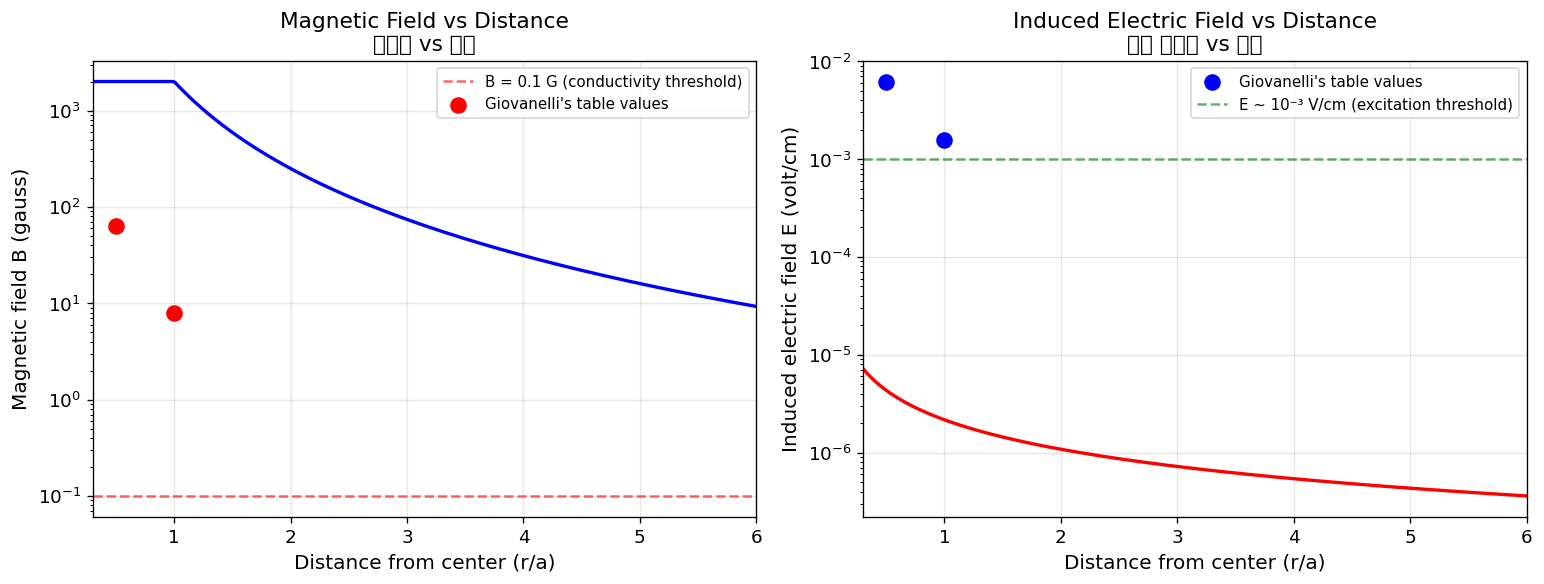

Figure 1: B and E fields vs distance from sunspot center.


In [3]:
# --- Plot: Induced E-field and B-field vs distance from sunspot ---
r_range = np.linspace(0.3 * a, 6 * a, 300)

# Magnetic field: dipole approximation B ~ B_max * (a/r)^3 for r > a
# (rough estimate matching Giovanelli's table)
B_dipole = B_max * (a / r_range)**3
B_dipole[r_range < a] = B_max  # inside sunspot, ~constant

# Induced electric field: E = dPhi/dt / (2*pi*r*c) in statV/cm -> volt/cm
E_induced = dPhi_dt / (2 * np.pi * r_range * c) / 299.79

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# --- B field ---
ax1.semilogy(r_range / a, B_dipole, "b-", lw=2)
ax1.axhline(y=0.1, color="red", ls="--", alpha=0.6, label="B = 0.1 G (conductivity threshold)")
ax1.scatter([1.0, 0.5], B_table, color="red", s=80, zorder=5, label="Giovanelli's table values")
ax1.set_xlabel("Distance from center (r/a)")
ax1.set_ylabel("Magnetic field B (gauss)")
ax1.set_title("Magnetic Field vs Distance\n자기장 vs 거리")
ax1.legend(fontsize=9)
ax1.set_xlim(0.3, 6)
ax1.grid(True, alpha=0.3)

# --- E field ---
ax2.semilogy(r_range / a, E_induced, "r-", lw=2)
ax2.scatter([1.0, 0.5], E_table, color="blue", s=80, zorder=5, label="Giovanelli's table values")
ax2.axhline(y=1e-3, color="green", ls="--", alpha=0.6, label="E ~ 10⁻³ V/cm (excitation threshold)")
ax2.set_xlabel("Distance from center (r/a)")
ax2.set_ylabel("Induced electric field E (volt/cm)")
ax2.set_title("Induced Electric Field vs Distance\n유도 전기장 vs 거리")
ax2.legend(fontsize=9)
ax2.set_xlim(0.3, 6)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("/Users/eunsupark/Projects/01_Personal/03_StudyWithAI/Solar_Physics/papers/18_giovanelli_1946/fig1_fields_vs_distance.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Figure 1: B and E fields vs distance from sunspot center.")

## 2. Ionization Condition / 이온화 조건

Giovanelli's key equation determines whether electrons can acquire enough energy to ionize hydrogen between collisions:

Giovanelli의 핵심 수식은 전자가 충돌 사이에 수소를 이온화할 만큼의 에너지를 얻을 수 있는지를 결정합니다:

$$\frac{E^2 \lambda^2}{1 + 8.8 \times 10^{-3} H^2 \lambda^2} \geq 2 \times 10^{15}$$

- At the **neutral point** ($H = 0$): the denominator is 1, so only $E\lambda$ matters → easy to satisfy
- In **magnetized regions** ($H \gg 0$): the denominator grows as $H^2$, suppressing excitation
- **중성점** ($H = 0$): 분모가 1이므로 $E\lambda$만 중요 → 쉽게 충족
- **자기장 영역** ($H \gg 0$): 분모가 $H^2$로 증가하여 여기 억제

/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_9524/934664273.py:76: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_9524/934664273.py:76: UserWarning: Glyph 50728 (\N{HANGUL SYLLABLE ON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_9524/934664273.py:76: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_9524/934664273.py:76: UserWarning: Glyph 51312 (\N{HANGUL SYLLABLE JO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_9524/934664273.py:76: UserWarning: Glyph 44148 (\N{HANGUL SYLLABLE GEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_9524/9346

Case 1: Neutral point (H = 0)
  E = 1e-03 volt/cm = 1e+05 EMU/cm
  Minimum λ for ionization: 447 cm
  Giovanelli's value:        450 cm
  This corresponds to mid-chromosphere (~6,000 km altitude)

Case 2: Strong magnetic field limit
  Maximum H for ionization: 2.38e-02 gauss
  Giovanelli's value:       7.5 × 10⁻² gauss
  → Essentially zero! Excitation impossible in magnetized regions.


/Users/eunsupark/Softwares/miniconda3/envs/study-with-ai/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/eunsupark/Softwares/miniconda3/envs/study-with-ai/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50728 (\N{HANGUL SYLLABLE ON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/eunsupark/Softwares/miniconda3/envs/study-with-ai/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/eunsupark/Softwares/miniconda3/envs/study-with-ai/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51312 (\N{HANGUL SYLLABLE JO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/eunsupark/Softwar

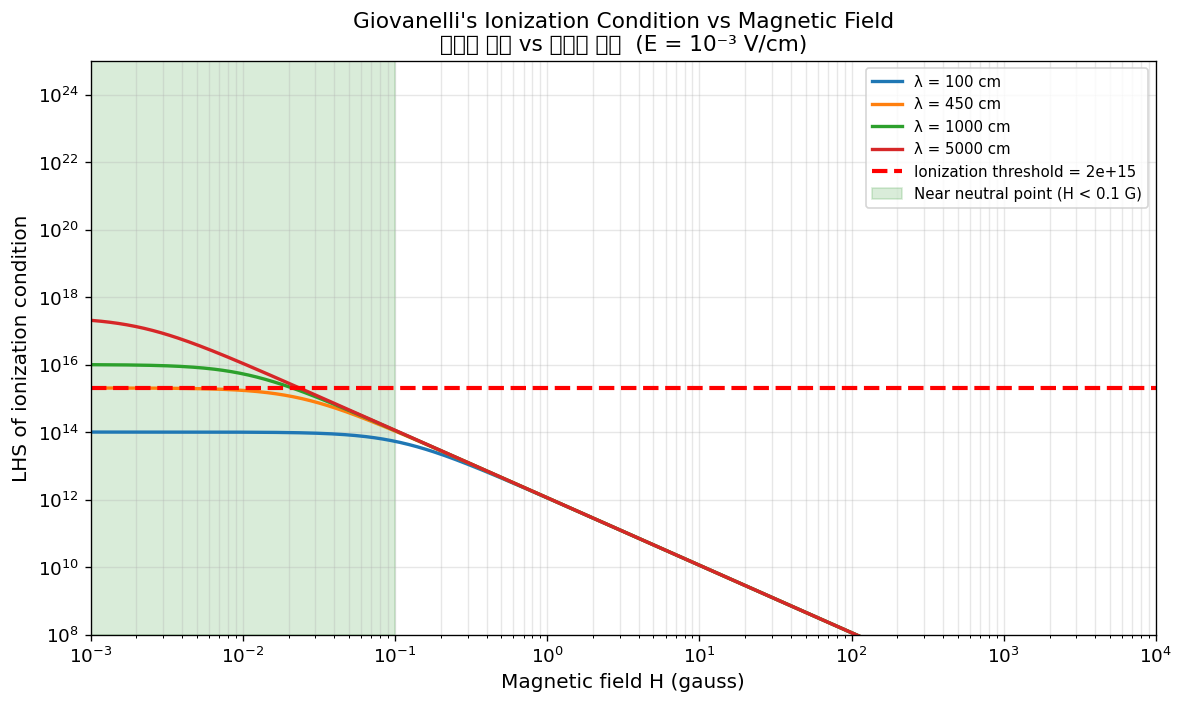


Key insight: Ionization is only possible at or very near the neutral point (H ≈ 0).


In [4]:
def ionization_lhs(E_emu, lam, H):
    """Compute the left-hand side of Giovanelli's ionization condition.

    Args:
        E_emu: Electric field in EMU (abV/cm).
        lam: Mean free path in cm.
        H: Magnetic field in gauss.

    Returns:
        LHS value; ionization occurs when LHS >= 2e15.
    """
    numerator = E_emu**2 * lam**2
    denominator = 1.0 + 8.8e-3 * H**2 * lam**2
    return numerator / denominator


# --- Giovanelli's worked example ---
# E = 10^-3 volt/cm = 10^-3 / (10^-8) EMU = 10^5 EMU
# (1 volt = 10^8 EMU of potential, so 1 V/cm = 10^8 / (10^2 * 3e10)...
# Actually: 1 V/cm = 1/299.79 statV/cm; in EMU: 1 V = 10^8 emu)
# Giovanelli uses EMU throughout. E in EMU = E_volt * 10^8 / 10^2 = E_volt * 10^6?
# Let's use his numbers directly:
# "if H=0, lambda >= 4.5e7/E. If E is 10^-3 volt/cm (10^5 EMU/cm), lambda >= 450 cm"
# Check: 4.5e7 / 10^5 = 450. Confirmed.

E_volt = 1e-3  # volt/cm (from table)

# Convert: the paper states E = 10^-3 volt/cm corresponds to 10^5 EMU
# This means 1 volt/cm = 10^8 EMU/cm in Giovanelli's convention
E_emu = E_volt * 1e8  # EMU/cm

# Threshold
threshold = 2e15

# Case 1: H = 0 (neutral point)
# Need E^2 * lam^2 >= 2e15
lam_min_H0 = np.sqrt(threshold) / E_emu
print("=" * 60)
print("Case 1: Neutral point (H = 0)")
print(f"  E = {E_volt:.0e} volt/cm = {E_emu:.0e} EMU/cm")
print(f"  Minimum λ for ionization: {lam_min_H0:.0f} cm")
print(f"  Giovanelli's value:        450 cm")
print(f"  This corresponds to mid-chromosphere (~6,000 km altitude)")

# Case 2: Strong field — find maximum H for ionization
# When 8.8e-3 * H^2 * lam^2 >> 1:
#   E^2 / (8.8e-3 * H^2) >= 2e15
#   H <= E / sqrt(8.8e-3 * 2e15) = E / (1.33e6)
H_max = E_emu / np.sqrt(8.8e-3 * threshold)
print(f"\nCase 2: Strong magnetic field limit")
print(f"  Maximum H for ionization: {H_max:.2e} gauss")
print(f"  Giovanelli's value:       7.5 × 10⁻² gauss")
print(f"  → Essentially zero! Excitation impossible in magnetized regions.")

# --- Visualization: Ionization condition as function of H ---
H_range = np.logspace(-3, 4, 500)  # 0.001 to 10,000 gauss
lam_values = [100, 450, 1000, 5000]  # cm

fig, ax = plt.subplots(figsize=(10, 6))

for lam in lam_values:
    lhs = ionization_lhs(E_emu, lam, H_range)
    ax.loglog(H_range, lhs, lw=2, label=f"λ = {lam} cm")

ax.axhline(y=threshold, color="red", ls="--", lw=2.5, label=f"Ionization threshold = {threshold:.0e}")
ax.axvspan(0.001, 0.1, alpha=0.15, color="green", label="Near neutral point (H < 0.1 G)")

ax.set_xlabel("Magnetic field H (gauss)")
ax.set_ylabel("LHS of ionization condition")
ax.set_title("Giovanelli's Ionization Condition vs Magnetic Field\n이온화 조건 vs 자기장 세기  (E = 10⁻³ V/cm)")
ax.legend(fontsize=9, loc="upper right")
ax.set_xlim(1e-3, 1e4)
ax.set_ylim(1e8, 1e25)
ax.grid(True, alpha=0.3, which="both")

plt.tight_layout()
plt.savefig("/Users/eunsupark/Projects/01_Personal/03_StudyWithAI/Solar_Physics/papers/18_giovanelli_1946/fig2_ionization_condition.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("\nKey insight: Ionization is only possible at or very near the neutral point (H ≈ 0).")

## 3. Drift Velocity / 드리프트 속도

The drift velocity of electrons in crossed electric and magnetic fields determines how effectively particles gain energy:

교차된 전기장과 자기장에서 전자의 드리프트 속도는 입자가 얼마나 효과적으로 에너지를 얻는지를 결정합니다:

$$v = \frac{Ee\tau}{m(1 + \omega^2\tau^2)}$$

At the neutral point ($\omega = 0$), $v = Ee\tau/m$ — maximum acceleration.
In strong fields ($\omega\tau \gg 1$), $v \approx Ee/(m\omega^2\tau)$ — drift is strongly suppressed.

중성점에서는 최대 가속, 강한 자기장에서는 드리프트가 강하게 억제됩니다.

/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_9524/674625716.py:55: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_9524/674625716.py:55: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_9524/674625716.py:55: UserWarning: Glyph 46300 (\N{HANGUL SYLLABLE DEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_9524/674625716.py:55: UserWarning: Glyph 47532 (\N{HANGUL SYLLABLE RI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_9524/674625716.py:55: UserWarning: Glyph 54532 (\N{HANGUL SYLLABLE PEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_9524/67

Thermal velocity at T=6000 K: 4.27e+07 cm/s
Collision time (τ):           1.06e-05 s
Cyclotron frequency at 1 G:   1.76e+07 rad/s


/Users/eunsupark/Softwares/miniconda3/envs/study-with-ai/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 46300 (\N{HANGUL SYLLABLE DEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/eunsupark/Softwares/miniconda3/envs/study-with-ai/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54532 (\N{HANGUL SYLLABLE PEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/eunsupark/Softwares/miniconda3/envs/study-with-ai/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 53944 (\N{HANGUL SYLLABLE TEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/eunsupark/Softwares/miniconda3/envs/study-with-ai/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49549 (\N{HANGUL SYLLABLE SOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


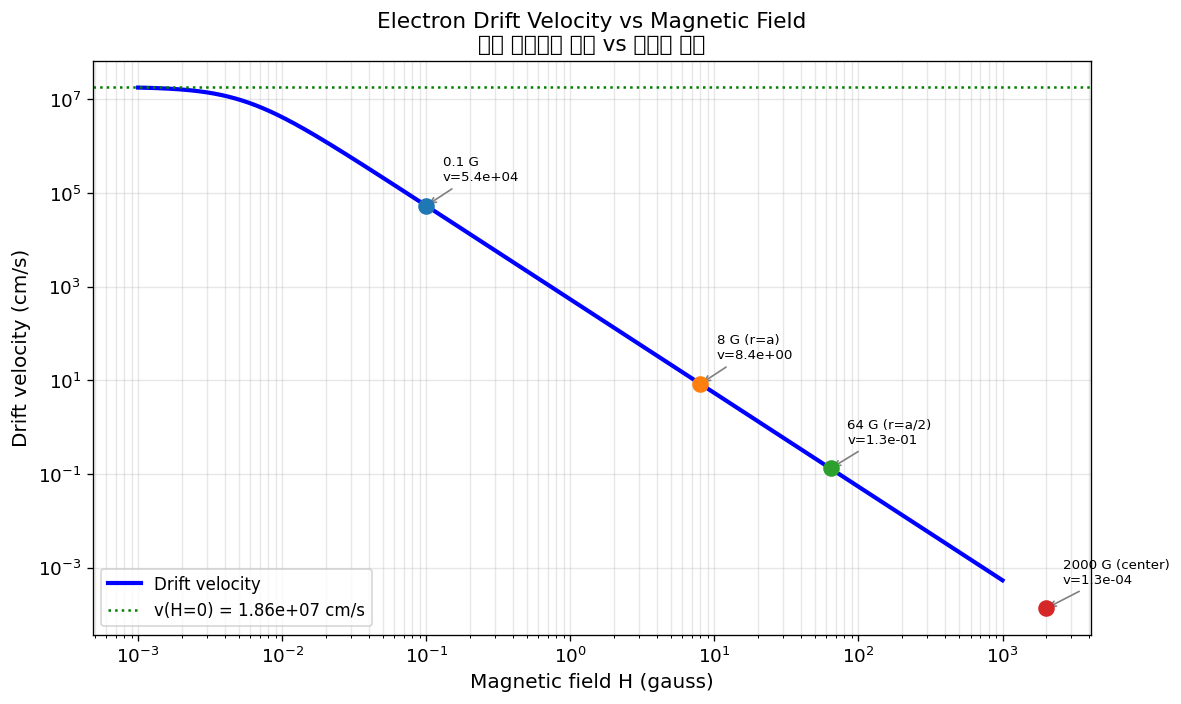


Drift velocity suppression:
  At H = 0 G (neutral point): v = 1.86e+07 cm/s
  At H = 0.1 G:  v = 5.37e+04 cm/s  (suppressed by 3e+02×)
  At H = 1 G:  v = 5.39e+02 cm/s  (suppressed by 3e+04×)
  At H = 8 G:  v = 8.42e+00 cm/s  (suppressed by 2e+06×)
  At H = 64 G:  v = 1.32e-01 cm/s  (suppressed by 1e+08×)
  At H = 2000 G:  v = 1.35e-04 cm/s  (suppressed by 1e+11×)


In [5]:
def drift_velocity(E_statV, H, tau):
    """Compute drift velocity of electrons in crossed E and B fields.

    Args:
        E_statV: Electric field in statV/cm.
        H: Magnetic field in gauss.
        tau: Mean time between collisions (seconds).

    Returns:
        Drift velocity in cm/s.
    """
    omega = e_cgs * H / (m_e * c)  # cyclotron frequency (rad/s)
    v = E_statV * e_cgs * tau / (m_e * (1 + omega**2 * tau**2))
    return v


# Chromospheric conditions
E_statV = E_volt / 299.79  # convert volt/cm to statV/cm

# Collision time in mid-chromosphere:
# mean free path ~ 450 cm, thermal velocity ~ 10^7 cm/s (T ~ 6000 K)
v_thermal = np.sqrt(2 * k_B * 6000 / m_e)
tau_collision = 450.0 / v_thermal
print(f"Thermal velocity at T=6000 K: {v_thermal:.2e} cm/s")
print(f"Collision time (τ):           {tau_collision:.2e} s")
print(f"Cyclotron frequency at 1 G:   {e_cgs / (m_e * c):.2e} rad/s")

# Drift velocity vs H
H_range = np.logspace(-3, 3, 500)
v_drift = drift_velocity(E_statV, H_range, tau_collision)
v_drift_H0 = drift_velocity(E_statV, 0, tau_collision)

fig, ax = plt.subplots(figsize=(10, 6))

ax.loglog(H_range, v_drift, "b-", lw=2.5, label="Drift velocity")
ax.axhline(y=v_drift_H0, color="green", ls=":", lw=1.5,
           label=f"v(H=0) = {v_drift_H0:.2e} cm/s")

# Mark key field strengths
for H_mark, label in [(0.1, "0.1 G"), (8, "8 G (r=a)"), (64, "64 G (r=a/2)"),
                        (2000, "2000 G (center)")]:
    v_mark = drift_velocity(E_statV, H_mark, tau_collision)
    ax.scatter([H_mark], [v_mark], s=80, zorder=5)
    ax.annotate(f"{label}\nv={v_mark:.1e}",
                xy=(H_mark, v_mark), xytext=(10, 15),
                textcoords="offset points", fontsize=8,
                arrowprops=dict(arrowstyle="->", color="gray"))

ax.set_xlabel("Magnetic field H (gauss)")
ax.set_ylabel("Drift velocity (cm/s)")
ax.set_title("Electron Drift Velocity vs Magnetic Field\n전자 드리프트 속도 vs 자기장 세기")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, which="both")

plt.tight_layout()
plt.savefig("/Users/eunsupark/Projects/01_Personal/03_StudyWithAI/Solar_Physics/papers/18_giovanelli_1946/fig3_drift_velocity.png",
            dpi=150, bbox_inches="tight")
plt.show()

# Suppression ratio
print(f"\nDrift velocity suppression:")
print(f"  At H = 0 G (neutral point): v = {v_drift_H0:.2e} cm/s")
for H_val in [0.1, 1, 8, 64, 2000]:
    v = drift_velocity(E_statV, H_val, tau_collision)
    print(f"  At H = {H_val} G:  v = {v:.2e} cm/s  (suppressed by {v_drift_H0/v:.0e}×)")

## 4. Chromospheric Conductivity / 채층 전도도

Cowling's formula for the conductivity of the solar atmosphere, cited by Giovanelli:

Giovanelli가 인용한 Cowling의 태양 대기 전도도 공식:

$$\sigma^l + i\sigma^{II} = \left\{6.8 \times 10^{13} \bar{Z} T^{-3/2} - i \, 8.6 \times 10^3 \frac{HT}{\rho_e}\right\}^{-1}$$

The direct conductivity ($\sigma^l$) operates along the electric field; the transverse conductivity ($\sigma^{II}$) operates perpendicular. In the presence of even a weak magnetic field, the transverse conductivity dominates and effectively blocks electron motion across field lines.

직접 전도도($\sigma^l$)는 전기장 방향으로, 횡방향 전도도($\sigma^{II}$)는 수직 방향으로 작용합니다. 약한 자기장에서도 횡방향 전도도가 지배적이 되어 자기력선을 가로지르는 전자 운동을 차단합니다.

/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_9524/4062728851.py:59: UserWarning: Glyph 52292 (\N{HANGUL SYLLABLE CAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_9524/4062728851.py:59: UserWarning: Glyph 52789 (\N{HANGUL SYLLABLE CEUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_9524/4062728851.py:59: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_9524/4062728851.py:59: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_9524/4062728851.py:59: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_

/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_9524/4062728851.py:59: UserWarning: Glyph 54848 (\N{HANGUL SYLLABLE HOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_9524/4062728851.py:59: UserWarning: Glyph 51649 (\N{HANGUL SYLLABLE JIG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_9524/4062728851.py:59: UserWarning: Glyph 51217 (\N{HANGUL SYLLABLE JEOB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_9524/4062728851.py:59: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_9524/4062728851.py:59: UserWarning: Glyph 50984 (\N{HANGUL SYLLABLE YUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_9

/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_9524/4062728851.py:60: UserWarning: Glyph 54848 (\N{HANGUL SYLLABLE HOL}) missing from font(s) DejaVu Sans.
  plt.savefig("/Users/eunsupark/Projects/01_Personal/03_StudyWithAI/Solar_Physics/papers/18_giovanelli_1946/fig4_conductivity.png",
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_9524/4062728851.py:60: UserWarning: Glyph 51649 (\N{HANGUL SYLLABLE JIG}) missing from font(s) DejaVu Sans.
  plt.savefig("/Users/eunsupark/Projects/01_Personal/03_StudyWithAI/Solar_Physics/papers/18_giovanelli_1946/fig4_conductivity.png",
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_9524/4062728851.py:60: UserWarning: Glyph 51217 (\N{HANGUL SYLLABLE JEOB}) missing from font(s) DejaVu Sans.
  plt.savefig("/Users/eunsupark/Projects/01_Personal/03_StudyWithAI/Solar_Physics/papers/18_giovanelli_1946/fig4_conductivity.png",
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_9524/4062728851.py:60: UserWarning: Glyph 4

/Users/eunsupark/Softwares/miniconda3/envs/study-with-ai/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 52292 (\N{HANGUL SYLLABLE CAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/eunsupark/Softwares/miniconda3/envs/study-with-ai/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 52789 (\N{HANGUL SYLLABLE CEUNG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/eunsupark/Softwares/miniconda3/envs/study-with-ai/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54848 (\N{HANGUL SYLLABLE HOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/eunsupark/Softwares/miniconda3/envs/study-with-ai/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51649 (\N{HANGUL SYLLABLE JIG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/eunsupark/S

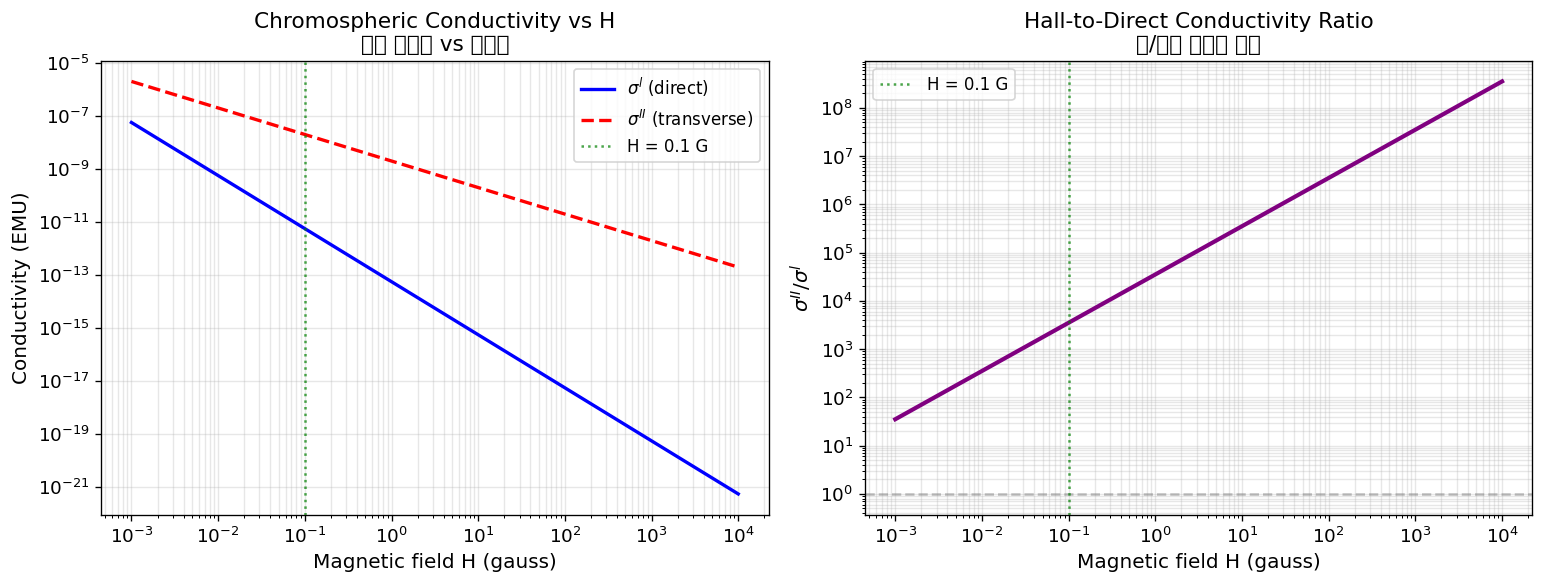


Conductivity at key field strengths:
  H =    0.00 G:  σ_direct = 6.83e-05 EMU (isotropic, no Hall)
  H =    0.01 G:  σ_direct = 5.50e-10,  σ_trans = 1.94e-07,  ratio = 352.7
  H =    0.10 G:  σ_direct = 5.50e-12,  σ_trans = 1.94e-08,  ratio = 3526.7
  H =    1.00 G:  σ_direct = 5.50e-14,  σ_trans = 1.94e-09,  ratio = 35266.9
  H =   10.00 G:  σ_direct = 5.50e-16,  σ_trans = 1.94e-10,  ratio = 352669.3
  H =  100.00 G:  σ_direct = 5.50e-18,  σ_trans = 1.94e-11,  ratio = 3526693.1
  H = 1000.00 G:  σ_direct = 5.50e-20,  σ_trans = 1.94e-12,  ratio = 35266930.7


In [6]:
def chromospheric_conductivity(Z_bar, T, H, rho_e):
    """Compute chromospheric direct and transverse conductivities (Cowling 1945).

    Args:
        Z_bar: Mean degree of ionization.
        T: Electron temperature (K).
        H: Magnetic field (gauss).
        rho_e: Electron pressure (dyne/cm^2).

    Returns:
        Tuple of (sigma_direct, sigma_transverse) in EMU.
    """
    # Resistivity components (inverse of conductivity)
    R = 6.8e13 * Z_bar * T**(-1.5)  # real part (resistive)
    X = 8.6e3 * H * T / rho_e       # imaginary part (Hall)

    # sigma = 1 / (R - iX) = (R + iX) / (R^2 + X^2)
    denom = R**2 + X**2
    sigma_direct = R / denom      # real part
    sigma_transverse = X / denom  # imaginary part
    return sigma_direct, sigma_transverse


# Typical mid-chromosphere parameters
T_chrom = 6000        # K
Z_bar = 1e-4          # mean ionization degree (very low in chromosphere)
rho_e = 0.1           # electron pressure (dyne/cm^2, approximate)

H_range = np.logspace(-3, 4, 500)

sigma_d = np.zeros_like(H_range)
sigma_t = np.zeros_like(H_range)
for i, H in enumerate(H_range):
    sigma_d[i], sigma_t[i] = chromospheric_conductivity(Z_bar, T_chrom, H, rho_e)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# --- Conductivities vs H ---
ax1.loglog(H_range, sigma_d, "b-", lw=2, label=r"$\sigma^l$ (direct)")
ax1.loglog(H_range, sigma_t, "r--", lw=2, label=r"$\sigma^{II}$ (transverse)")
ax1.axvline(x=0.1, color="green", ls=":", alpha=0.7, label="H = 0.1 G")
ax1.set_xlabel("Magnetic field H (gauss)")
ax1.set_ylabel("Conductivity (EMU)")
ax1.set_title("Chromospheric Conductivity vs H\n채층 전도도 vs 자기장")
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3, which="both")

# --- Ratio sigma_transverse / sigma_direct ---
ratio = sigma_t / sigma_d
ax2.loglog(H_range, ratio, "purple", lw=2.5)
ax2.axhline(y=1, color="gray", ls="--", alpha=0.5)
ax2.axvline(x=0.1, color="green", ls=":", alpha=0.7, label="H = 0.1 G")
ax2.set_xlabel("Magnetic field H (gauss)")
ax2.set_ylabel(r"$\sigma^{II} / \sigma^l$")
ax2.set_title("Hall-to-Direct Conductivity Ratio\n홀/직접 전도도 비율")
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3, which="both")

plt.tight_layout()
plt.savefig("/Users/eunsupark/Projects/01_Personal/03_StudyWithAI/Solar_Physics/papers/18_giovanelli_1946/fig4_conductivity.png",
            dpi=150, bbox_inches="tight")
plt.show()

# Print key values
print("\nConductivity at key field strengths:")
for H_val in [0, 0.01, 0.1, 1, 10, 100, 1000]:
    if H_val == 0:
        sd = 1 / (6.8e13 * Z_bar * T_chrom**(-1.5))
        print(f"  H = {H_val:7.2f} G:  σ_direct = {sd:.2e} EMU (isotropic, no Hall)")
    else:
        sd, st = chromospheric_conductivity(Z_bar, T_chrom, H_val, rho_e)
        print(f"  H = {H_val:7.2f} G:  σ_direct = {sd:.2e},  σ_trans = {st:.2e},  ratio = {st/sd:.1f}")

## 5. Neutral Point Geometry / 중성점 기하학

A neutral point forms where the sunspot's magnetic field cancels the external (background) field. We visualize a 2D magnetic field topology showing a sunspot dipole superposed with a uniform external field, revealing the X-type neutral point where $\mathbf{B} = 0$.

중성점은 흑점의 자기장이 외부(배경) 자기장과 상쇄되는 곳에서 형성됩니다. 흑점 쌍극자와 균일 외부 자기장을 중첩하여 $\mathbf{B} = 0$인 X-형 중성점을 시각화합니다.

This is the geometry Giovanelli had in mind: the neutral point sits in the chromosphere above or below the sunspot, and it is at this location that electron acceleration and flare emission occur.

이것이 Giovanelli가 구상한 기하학입니다: 중성점은 흑점 위 또는 아래의 채층에 위치하며, 이 위치에서 전자 가속과 플레어 방출이 발생합니다.

Neutral point location (analytical): z = 2.924 (in sunspot radii)


/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_9524/3467872566.py:101: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_9524/3467872566.py:101: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_9524/3467872566.py:101: UserWarning: Glyph 51109 (\N{HANGUL SYLLABLE JANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_9524/3467872566.py:101: UserWarning: Glyph 49440 (\N{HANGUL SYLLABLE SEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_9524/3467872566.py:101: UserWarning: Glyph 44284 (\N{HANGUL SYLLABLE GWA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipyker

/Users/eunsupark/Softwares/miniconda3/envs/study-with-ai/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49440 (\N{HANGUL SYLLABLE SEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/eunsupark/Softwares/miniconda3/envs/study-with-ai/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44284 (\N{HANGUL SYLLABLE GWA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/eunsupark/Softwares/miniconda3/envs/study-with-ai/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/eunsupark/Softwares/miniconda3/envs/study-with-ai/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/eunsupark

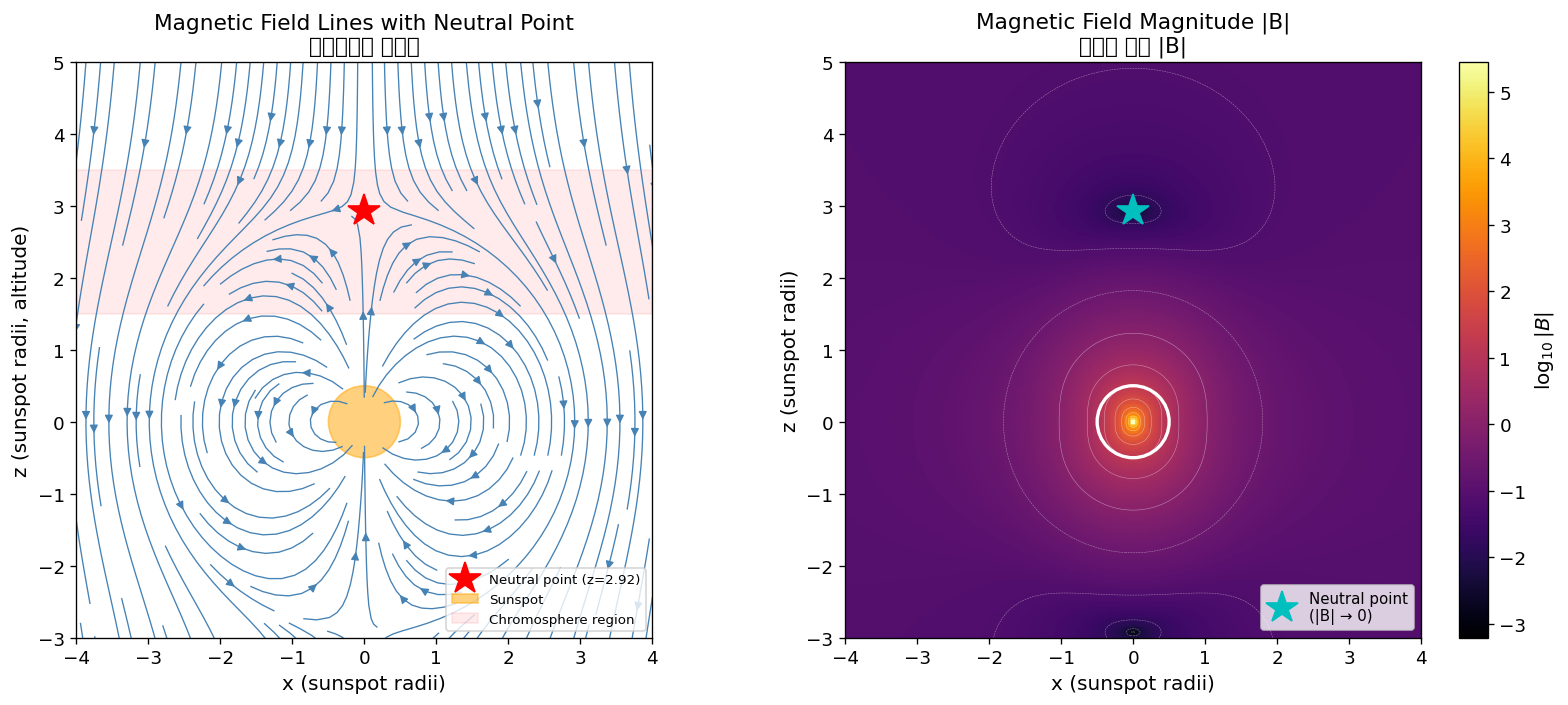


The neutral point (red/cyan star) is where |B| = 0.
This is where Giovanelli proposed electron acceleration and flare emission occur.


In [7]:
def magnetic_dipole_field(x, z, m, x0=0, z0=0):
    """Compute the magnetic field of a vertical dipole at (x0, z0).

    Args:
        x, z: Coordinates (can be arrays).
        m: Magnetic dipole moment (positive = upward).
        x0, z0: Dipole location.

    Returns:
        Tuple of (Bx, Bz) field components.
    """
    dx = x - x0
    dz = z - z0
    r2 = dx**2 + dz**2
    r5 = r2**(5/2)
    r5 = np.where(r5 < 1e-30, 1e-30, r5)  # avoid division by zero

    Bx = 3 * m * dx * dz / r5
    Bz = m * (3 * dz**2 - r2) / r5
    return Bx, Bz


# --- Setup: sunspot dipole + uniform external field ---
# Normalized units: sunspot at origin, radius = 1
m_spot = 1.0        # dipole moment (arbitrary units)
B_ext = 0.08        # uniform external field (vertical, downward)

# Grid
nx, nz = 400, 400
x = np.linspace(-5, 5, nx)
z = np.linspace(-5, 5, nz)
X, Z = np.meshgrid(x, z)

# Sunspot dipole (positive polarity = field points up)
Bx_dip, Bz_dip = magnetic_dipole_field(X, Z, m_spot)

# Uniform external field (pointing downward to create a neutral point above)
Bx_ext = 0.0
Bz_ext = -B_ext

# Total field
Bx_tot = Bx_dip + Bx_ext
Bz_tot = Bz_dip + Bz_ext
B_mag = np.sqrt(Bx_tot**2 + Bz_tot**2)

# Find the neutral point (minimum of |B|) above the dipole
# Analytical: on axis (x=0), Bz = m * 2/z^3 - B_ext = 0  =>  z_np = (2m/B_ext)^(1/3)
z_neutral = (2 * m_spot / B_ext)**(1/3)
print(f"Neutral point location (analytical): z = {z_neutral:.3f} (in sunspot radii)")

# --- Visualization ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Panel 1: Field lines (streamplot)
ax = axes[0]
# Mask near the dipole to avoid singularity
mask = np.sqrt(X**2 + Z**2) < 0.3
Bx_plot = np.where(mask, np.nan, Bx_tot)
Bz_plot = np.where(mask, np.nan, Bz_tot)

speed = np.sqrt(Bx_plot**2 + Bz_plot**2)
lw = 2.0 * speed / np.nanmax(speed)

ax.streamplot(X, Z, Bx_plot, Bz_plot, color="steelblue",
              density=1.8, linewidth=0.8, arrowsize=1.0)

# Mark neutral point
ax.plot(0, z_neutral, "r*", ms=20, zorder=10, label=f"Neutral point (z={z_neutral:.2f})")
ax.add_patch(Circle((0, 0), 0.5, fill=True, color="orange", alpha=0.5, label="Sunspot"))

# Chromosphere band (approximate)
ax.axhspan(1.5, 3.5, alpha=0.08, color="red", label="Chromosphere region")

ax.set_xlabel("x (sunspot radii)")
ax.set_ylabel("z (sunspot radii, altitude)")
ax.set_title("Magnetic Field Lines with Neutral Point\n자기장선과 중성점")
ax.legend(fontsize=8, loc="lower right")
ax.set_xlim(-4, 4)
ax.set_ylim(-3, 5)
ax.set_aspect("equal")

# Panel 2: |B| magnitude map
ax = axes[1]
B_log = np.log10(np.clip(B_mag, 1e-5, None))
im = ax.pcolormesh(X, Z, B_log, cmap="inferno", shading="auto")
ax.contour(X, Z, B_log, levels=15, colors="white", linewidths=0.3, alpha=0.5)

# Neutral point
ax.plot(0, z_neutral, "c*", ms=20, zorder=10, label=f"Neutral point\n(|B| → 0)")
ax.add_patch(Circle((0, 0), 0.5, fill=False, edgecolor="white", lw=2))

cbar = plt.colorbar(im, ax=ax, label=r"$\log_{10}|B|$")
ax.set_xlabel("x (sunspot radii)")
ax.set_ylabel("z (sunspot radii)")
ax.set_title("Magnetic Field Magnitude |B|\n자기장 세기 |B|")
ax.legend(fontsize=9, loc="lower right")
ax.set_xlim(-4, 4)
ax.set_ylim(-3, 5)
ax.set_aspect("equal")

plt.tight_layout()
plt.savefig("/Users/eunsupark/Projects/01_Personal/03_StudyWithAI/Solar_Physics/papers/18_giovanelli_1946/fig5_neutral_point.png",
            dpi=150, bbox_inches="tight")
plt.show()
print(f"\nThe neutral point (red/cyan star) is where |B| = 0.")
print(f"This is where Giovanelli proposed electron acceleration and flare emission occur.")

## 6. Flare Energy Budget / 플레어 에너지 예산

We estimate the total magnetic energy available for a flare event using Giovanelli's sunspot parameters, and compare with observed flare energies.

Giovanelli의 흑점 매개변수를 사용하여 플레어 이벤트에 사용 가능한 총 자기 에너지를 추정하고, 관측된 플레어 에너지와 비교합니다.

$$E_{\text{flare}} \sim \frac{B^2}{8\pi} V$$

/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_9524/2690067437.py:64: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_9524/2690067437.py:64: UserWarning: Glyph 50857 (\N{HANGUL SYLLABLE YONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_9524/2690067437.py:64: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_9524/2690067437.py:64: UserWarning: Glyph 45733 (\N{HANGUL SYLLABLE NEUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_9524/2690067437.py:64: UserWarning: Glyph 54620 (\N{HANGUL SYLLABLE HAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_9

   B (G) |     L (cm) |   Volume (cm³) |    E_mag (erg) |  Flare class
------------------------------------------------------------------------
     100 |      1e+08 |       1.00e+24 |       3.98e+26 |   < Subflare
     100 |      5e+08 |       1.25e+26 |       4.97e+28 |   < Subflare
     100 |      1e+09 |       1.00e+27 |       3.98e+29 |     Subflare
     100 |      5e+09 |       1.25e+29 |       4.97e+31 |      M-class
------------------------------------------------------------------------
     500 |      1e+08 |       1.00e+24 |       9.95e+27 |   < Subflare
     500 |      5e+08 |       1.25e+26 |       1.24e+30 |      C-class
     500 |      1e+09 |       1.00e+27 |       9.95e+30 |      C-class
     500 |      5e+09 |       1.25e+29 |       1.24e+33 |         X10+
------------------------------------------------------------------------
    1000 |      1e+08 |       1.00e+24 |       3.98e+28 |   < Subflare
    1000 |      5e+08 |       1.25e+26 |       4.97e+30 |      C-class


/Users/eunsupark/Softwares/miniconda3/envs/study-with-ai/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/eunsupark/Softwares/miniconda3/envs/study-with-ai/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50857 (\N{HANGUL SYLLABLE YONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/eunsupark/Softwares/miniconda3/envs/study-with-ai/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/eunsupark/Softwares/miniconda3/envs/study-with-ai/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 45733 (\N{HANGUL SYLLABLE NEUNG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/eunsupark/Sof

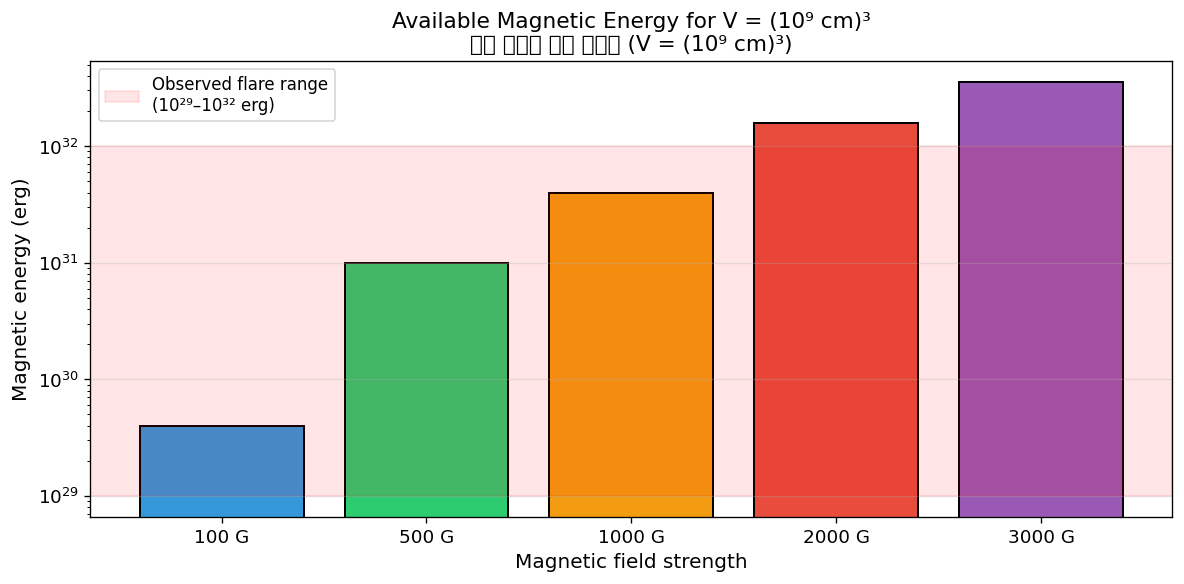

In [8]:
# --- Flare energy budget ---
# Magnetic energy density: u_B = B^2 / (8*pi)  [erg/cm^3]

B_values = [100, 500, 1000, 2000, 3000]  # gauss
# Characteristic volumes: from small to large flare regions
L_values = [1e8, 5e8, 1e9, 5e9]  # cm (side length of cube)

print("=" * 72)
print(f"{'B (G)':>8} | {'L (cm)':>10} | {'Volume (cm³)':>14} | {'E_mag (erg)':>14} | {'Flare class':>12}")
print("-" * 72)

flare_classes = [
    (1e29, "Subflare"),
    (1e30, "C-class"),
    (1e31, "M-class"),
    (1e32, "X-class"),
    (1e33, "X10+"),
]

for B in B_values:
    u_B = B**2 / (8 * np.pi)
    for L in L_values:
        V = L**3
        E_mag = u_B * V
        # Classify
        fclass = "< Subflare"
        for threshold_e, name in flare_classes:
            if E_mag >= threshold_e:
                fclass = name
        print(f"{B:8d} | {L:10.0e} | {V:14.2e} | {E_mag:14.2e} | {fclass:>12}")
    print("-" * 72)

# Giovanelli's specific case
B_g = 2000
L_g = 1e9  # ~10,000 km — typical flare region
V_g = L_g**3
E_g = B_g**2 / (8 * np.pi) * V_g
print(f"\nGiovanelli's sunspot case:")
print(f"  B = {B_g} G, L = {L_g:.0e} cm ({L_g/1e5:.0f} km)")
print(f"  Magnetic energy = {E_g:.2e} erg")
print(f"  Observed flare energies: 10²⁹ – 10³² erg")
print(f"  → Sufficient to power a major flare!")

# --- Bar chart ---
fig, ax = plt.subplots(figsize=(10, 5))

B_plot = [100, 500, 1000, 2000, 3000]
E_plot = [(B**2 / (8*np.pi)) * (1e9)**3 for B in B_plot]

bars = ax.bar(range(len(B_plot)), E_plot, color=["#3498db", "#2ecc71", "#f39c12", "#e74c3c", "#9b59b6"],
              edgecolor="black", lw=1.2)
ax.set_xticks(range(len(B_plot)))
ax.set_xticklabels([f"{B} G" for B in B_plot])
ax.set_ylabel("Magnetic energy (erg)")
ax.set_xlabel("Magnetic field strength")
ax.set_title(f"Available Magnetic Energy for V = (10⁹ cm)³\n이용 가능한 자기 에너지 (V = (10⁹ cm)³)")
ax.set_yscale("log")

# Observed flare energy range
ax.axhspan(1e29, 1e32, alpha=0.1, color="red", label="Observed flare range\n(10²⁹–10³² erg)")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("/Users/eunsupark/Projects/01_Personal/03_StudyWithAI/Solar_Physics/papers/18_giovanelli_1946/fig6_energy_budget.png",
            dpi=150, bbox_inches="tight")
plt.show()

## Summary / 요약

This notebook reproduced the key quantitative results from Giovanelli (1946):

이 노트북은 Giovanelli (1946)의 핵심 정량적 결과를 재현했습니다:

1. **Sunspot coil model**: Computed induced electric fields (~10⁻³ V/cm) matching Giovanelli's table values
   흑점 코일 모델: Giovanelli의 표 값과 일치하는 유도 전기장(~10⁻³ V/cm) 계산

2. **Ionization condition**: Demonstrated that hydrogen excitation is only possible at the neutral point (H ≈ 0), not in magnetized regions
   이온화 조건: 수소 여기가 자화된 영역이 아닌 중성점(H ≈ 0)에서만 가능함을 증명

3. **Drift velocity**: Showed ~10 orders of magnitude suppression of electron drift in sunspot-strength fields vs. the neutral point
   드리프트 속도: 흑점 자기장에서 중성점 대비 ~10차수의 전자 드리프트 억제를 표시

4. **Chromospheric conductivity**: Confirmed that even weak fields (~0.1 G) make conductivity highly anisotropic, confining currents to field lines
   채층 전도도: 약한 자기장(~0.1 G)에서도 전도도가 매우 비등방적이 되어 전류를 자기력선에 속박함을 확인

5. **Neutral point geometry**: Visualized the X-point topology where opposite-polarity fields cancel — the site of future "magnetic reconnection"
   중성점 기하학: 반대 극성 자기장이 상쇄되는 X-점 위상 — 미래의 "자기 재결합" 장소를 시각화

6. **Energy budget**: Verified that magnetic energy in sunspot regions ($\sim 10^{31}$ erg) is sufficient to power observed flares
   에너지 예산: 흑점 영역의 자기 에너지($\sim 10^{31}$ erg)가 관측된 플레어를 구동하기에 충분함을 검증